# Artificial Intelligence - Coursework

In this project, we will use the BreastMinist dataset so let's first install the MedMnist package.

For more information about MedMnist, please refer to https://medmnist.com/


In [ ]:
# Install MedMNIST
!pip install medmnist

In [ ]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [ ]:
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

In [ ]:
data_flag = 'breastmnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

## First, we read the MedMNIST data, preprocess them and encapsulate them into dataloader form.

In [ ]:
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [ ]:
print(train_dataset)
print("===================")
print(test_dataset)

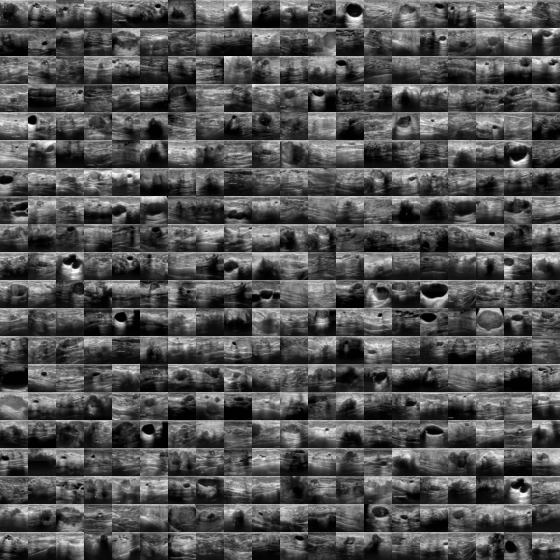

In [ ]:
# montage
train_dataset.montage(length=20)

## Then, we define a simple model for illustration, object function and optimizer that we use to classify.

In [ ]:
# define a simple CNN model

class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = Net(in_channels=n_channels, num_classes=n_classes)

# define loss function and optimizer
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

## Next, we can start to train and evaluate!

In [ ]:
# train

for epoch in range(20):
    train_correct = 0
    train_total = 0
    test_correct = 0
    test_total = 0

    model.train()
    for inputs, targets in tqdm(train_loader):
        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(inputs)

        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

In [ ]:
# evaluation

def test(split):
    model.eval()
    y_true = torch.tensor([])
    y_score = torch.tensor([])

    data_loader = train_loader_at_eval if split == 'train' else test_loader

    with torch.no_grad():
        for inputs, targets in data_loader:
            outputs = model(inputs)

            if task == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                outputs = outputs.softmax(dim=-1)
            else:
                targets = targets.squeeze().long()
                outputs = outputs.softmax(dim=-1)
                targets = targets.float().resize_(len(targets), 1)

            y_true = torch.cat((y_true, targets), 0)
            y_score = torch.cat((y_score, outputs), 0)

        y_true = y_true.numpy()
        y_score = y_score.detach().numpy()

        evaluator = Evaluator(data_flag, split)
        metrics = evaluator.evaluate(y_score)

        print('%s \n AUC: %.3f  ACC:%.3f' % ('Train set results' if split == 'train' else 'Test set results', *metrics))


print('==> Evaluating ...')
test('train')
test('test')

##Here is the main logic, that I implemented




In [ ]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, average_precision_score, precision_recall_curve,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Accuracy function supporting both PyTorch tensors and NumPy arrays
def accuracy(output, target):
    if isinstance(output, torch.Tensor):
        pred = output.argmax(dim=1)
        correct = pred.eq(target).sum().item()
    else:  # For numpy arrays
        if output.ndim == 1:
            pred = (output > 0.5).astype(int)
        else:
            pred = np.argmax(output, axis=1)
        correct = np.sum(pred == target)
    return correct / len(target)

# Set device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify the first convolution to accept grayscale images (1 channel)
model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)

# Remove the first MaxPooling layer (too aggressive for small images like 28x28)
model.maxpool = nn.Identity()

# Change the output layer to binary classification (2 classes: malignant vs benign/normal)
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to device
model = model.to(device)

# Training hyperparameters
epochs = 30
batchSize = 128
lr = 0.001
weight_decay = 0.01

# Optimizer, loss function, and learning rate scheduler
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)  # Decay LR every 5 epochs

# Early stopping and best model tracking
best_val_acc = 0.0
best_val_auc = 0.0
patience = 5
no_improve = 0

# Training loop
for epoch in range(epochs):
    model.train()
    running_acc = 0.0
    running_loss = 0.0

    # Training phase
    for inputs, targets in tqdm(train_loader, desc=f"Epoch-{epoch+1}"):
        inputs, targets = inputs.to(device), targets.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy(outputs, targets)

    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)
    print(f'Train - Loss: {train_loss:.6f}, Accuracy: {train_acc*100:.2f}%')

    # Validation phase
    model.eval()
    val_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for data, label in test_loader:
            data, label = data.to(device), label.squeeze().long().to(device)
            outputs = model(data)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Get probability for the positive class

            loss = criterion(outputs, label)
            val_loss += loss.item()

            all_labels.extend(label.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Convert labels and predictions to NumPy arrays
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    preds = (all_probs > 0.5).astype(int)

    val_loss /= len(test_loader)
    val_acc = accuracy(all_probs, all_labels)
    val_auc = roc_auc_score(all_labels, all_probs)

    # Check if predictions include both classes (avoid errors in metric calculation)
    if len(np.unique(preds)) > 1:
        val_precision = precision_score(all_labels, preds)
        val_recall = recall_score(all_labels, preds)
        val_f1 = f1_score(all_labels, preds)
    else:
        val_precision = 0.0
        val_recall = 0.0
        val_f1 = 0.0

    val_aupr = average_precision_score(all_labels, all_probs)

    # Print validation metrics
    print(f'Test - Loss: {val_loss:.6f}, Accuracy: {val_acc*100:.2f}%')
    print(f'AUC: {val_auc:.4f}, AUPR: {val_aupr:.4f}')
    print(f'Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}')

    # Save the best model (based on AUC and then accuracy)
    if val_auc > best_val_auc or (val_auc == best_val_auc and val_acc > best_val_acc):
        best_val_acc = val_acc
        best_val_auc = val_auc
        no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'New best model saved (Acc: {val_acc*100:.2f}%, AUC: {val_auc:.4f})')
    else:
        no_improve += 1
        if no_improve == patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load('best_model.pth'))
            print(f"====Best model performances====")
            print(f'Test - Loss: {val_loss:.6f}, Accuracy: {val_acc*100:.2f}%')
            print(f'AUC: {val_auc:.4f}, AUPR: {val_aupr:.4f}')
            print(f'Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}')
            break

    scheduler.step()

# === Evaluation and Visualization Functions ===

def plot_roc_curve(labels, probs):
    """
    Plot the Receiver Operating Characteristic (ROC) curve and compute AUC.
    """
    fpr, tpr, _ = roc_curve(labels, probs)
    aucScore = roc_auc_score(labels, probs)

    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {aucScore:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

def plot_precision_recall(labels, probs):
    """
    Plot the Precision-Recall curve and compute AUPR.
    """
    precision, recall, _ = precision_recall_curve(labels, probs)
    aupr = average_precision_score(labels, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'AUPR = {aupr:.3f}', color='darkorange')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid()
    plt.show()

def plot_confusion_matrix(labels, probs):
    """
    Display the confusion matrix.
    """
    preds = (np.array(probs) > 0.5).astype(int)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

# === Final Evaluation with the Best Model ===

# Load the best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Collect predictions on the full test set
all_labels, all_probs = [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_labels.extend(targets.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Plot evaluation curves and metrics
plot_roc_curve(all_labels, all_probs)
plot_precision_recall(all_labels, all_probs)
plot_confusion_matrix(all_labels, all_probs)


In [ ]:
from sklearn.model_selection import KFold
import torch.utils.data as data

def accuracy(output, target):
    # Ensure target is always numpy array for consistent handling
    target = np.array(target)
    if isinstance(output, torch.Tensor):
        pred = output.argmax(dim=1).cpu().numpy()
    else:
        output = np.array(output)
        pred = (output > 0.5).astype(int) if output.ndim == 1 else np.argmax(output, axis=1)
    # Ensure shapes match and convert to same type
    pred = pred.reshape(-1)
    target = target.reshape(-1).astype(pred.dtype)

    correct = np.sum(pred == target)
    return correct / len(target)

# Combine all data for cross-validation
full_dataset = data.ConcatDataset([train_dataset, test_dataset])
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
fold_results = {
    'fold': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': [],
    'val_auc': [],
    'test_auc': []
}

for fold, (train_val_idx, test_idx) in enumerate(kf.split(range(len(full_dataset)))):
    print(f"\n-- Fold {fold+1}/5 --")

    # Split into train+val (80%) and test (20%)
    train_val_data = data.Subset(full_dataset, train_val_idx)
    test_data = data.Subset(full_dataset, test_idx)

    # Split train_val into train (75%) and val (25%)
    train_idx = range(0, int(0.75*len(train_val_data)))
    val_idx = range(int(0.75*len(train_val_data)), len(train_val_data))

    train_data = data.Subset(train_val_data, train_idx)
    val_data = data.Subset(train_val_data, val_idx)

    train_loader = data.DataLoader(train_data, batch_size=128, shuffle=True)
    val_loader = data.DataLoader(val_data, batch_size=128)
    test_loader = data.DataLoader(test_data, batch_size=128)

    # Initialize model for this fold
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 2)
    model = model.to(device)

    # Training setup
    epochs = 30
    batchSize = 128
    lr = 0.001
    weight_decay =0.01

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) #reduce LR every 5 epochs

    best_val_auc = 0.0
    best_val_acc = 0.0
    patience = 3
    no_improve = 0

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_acc = 0.0
        running_loss = 0.0

        for inputs, targets in tqdm(train_loader, desc=f"Epoch-{epoch+1}"):
            inputs, targets = inputs.to(device), targets.squeeze().long().to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_acc += accuracy(outputs, targets)

        train_loss = running_loss / len(train_loader)
        train_acc = running_acc / len(train_loader)
        print(f'Train - Loss: {train_loss:.6f}, Accuracy: {train_acc*100:.2f}%')

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.squeeze().long().to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)[:, 1]

                loss = criterion(outputs, targets)
                val_loss += loss.item()

                all_labels.extend(targets.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)
        preds = (all_probs > 0.5).astype(int)

        val_loss /= len(val_loader)
        val_acc = accuracy(all_probs, all_labels)
        val_auc = roc_auc_score(all_labels, all_probs)


        print(f'Test - Loss: {val_loss:.6f}, Accuracy: {val_acc*100:.2f}%')
        print(f'AUC: {val_auc:.4f}, AUPR: {val_aupr:.4f}')

        # Early stopping
        if val_auc > best_val_auc or (val_auc == best_val_auc and val_acc > best_val_acc):
            best_val_auc = val_auc
            best_val_acc = val_acc
            no_improve = 0
            torch.save(model.state_dict(), f'best_fold{fold+1}.pth')
            print(f'New best model saved (Acc: {val_acc*100:.2f}%, AUC: {val_auc:.4f})')
        else:
            no_improve += 1
            if no_improve == patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        scheduler.step()

    # Test phase (using best model from this fold)
    model.load_state_dict(torch.load(f'best_fold{fold+1}.pth'))
    model.eval()

    # Evaluate on validation set
    val_labels, val_probs = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs.to(device))
            val_probs.extend(torch.softmax(outputs, dim=1)[:,1].cpu().numpy())
            val_labels.extend(targets.cpu().numpy())

    val_acc = accuracy(val_probs, val_labels)
    val_auc = roc_auc_score(val_labels, val_probs)

    # Evaluate on test set
    test_labels, test_probs = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs.to(device))
            test_probs.extend(torch.softmax(outputs, dim=1)[:,1].cpu().numpy())
            test_labels.extend(targets.cpu().numpy())

    test_acc = accuracy(test_probs, test_labels)
    test_auc = roc_auc_score(test_labels, test_probs)

    # Store results
    fold_results['fold'].append(fold+1)
    fold_results['train_acc'].append(train_acc)
    fold_results['val_acc'].append(val_acc)
    fold_results['test_acc'].append(test_acc)
    fold_results['val_auc'].append(val_auc)
    fold_results['test_auc'].append(test_auc)

    print(f"\nFold {fold+1} Results:")
    print(f"Validation - Accuracy: {val_acc*100:.2f}%, AUC: {val_auc:.4f}")
    print(f"Test - Accuracy: {test_acc*100:.2f}%, AUC: {test_auc:.4f}")

# Final results
print("\n=== Final 5-Fold CV Results ===")
print(f"Average Training Accuracy: {np.mean(fold_results['train_acc'])*100:.2f}%")
print(f"Average Validation Accuracy: {np.mean(fold_results['val_acc'])*100:.2f}%")
print(f"Average Test Accuracy: {np.mean(fold_results['test_acc'])*100:.2f}%")
print(f"Average Validation AUC: {np.mean(fold_results['val_auc']):.4f}")
print(f"Average Test AUC: {np.mean(fold_results['test_auc']):.4f}")

# Plot results from last fold (or you could average across folds)
plot_roc_curve(test_labels, test_probs)
plot_precision_recall(test_labels, test_probs)
plot_confusion_matrix(test_labels, test_probs)

End of the notebook.